# Lichess Bullet Chess Performance Analysis

A data analysis of ~28,800 rated and casual chess games played on
[Lichess.org](https://lichess.org), exported as a PGN file and analyzed with
pandas, SQL and scikit-learn.

**Questions answered:**
- Which time control do I perform best in?
- Does the white-piece advantage show up in my own results?
- How has my activity changed over time?
- Does my win rate drop against much higher-rated opponents?
- What time of day do I play best?
- Which openings win me the most games?
- Is my success driven by tactics/skill or by winning on the clock?
- Which single factor (rating gap, color, time pressure, hour) predicts a
  game's outcome best?

> **Note on reconstruction:** this notebook was rebuilt from an earlier
> version whose saved file was missing a few intermediate cells (visible
> only through leftover outputs referencing undefined variables). Every
> cell below that fills one of those gaps is marked **[RECONSTRUCTED]** in
> its markdown header, with the assumption it makes stated explicitly.


## Setup

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

from data_pipeline import (
    NICKNAME, RANKED_EVENTS, ML_FEATURES,
    parse_pgn, clean_games, enrich_games,
    build_opening_stats, build_ml_dataset,
)

pd.set_option('display.max_columns', 50)


## 1. Data Extraction

Lichess exports game history as a single text file containing one PGN
(Portable Game Notation) block per game: a set of `[Tag "value"]` header
lines followed by the move list. `parse_pgn` (in `data_pipeline.py`) walks
the file line by line and turns every game into one row of a DataFrame.


In [2]:
raw_df = parse_pgn('../data/raw/my_lichess_history.txt')
print(raw_df.shape)
raw_df.head()


(28838, 21)


,Event,Site,Date,White,Black,Result,UTCDate,UTCTime,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,BlackTitle,Variant,TimeControl,ECO,Termination,Moves,WhiteTitle,FEN,SetUp
0,Rated bullet game,https://lichess.org/oECdV8Ew,2024.12.12,VladTheBest,legend2014,1-0,2024.12.12,18:01:22,2919,3050,+8,-8,FM,Standard,60+0,A56,Normal,,None,NaN,NaN
1,Rated bullet game,https://lichess.org/f6smS9O0,2024.12.12,legend2014,sid-al_1979,0-1,2024.12.12,17:58:13,3059,2754,-9,+10,FM,Standard,60+0,B51,Normal,1. d4 Nf6 2. c4 c5 3. dxc5 e6 4. Nf3 Bxc5 5. e...,FM,NaN,NaN
2,Rated bullet game,https://lichess.org/vi4fXJ2z,2024.12.12,SantosBarrios,legend2014,0-1,2024.12.12,15:24:25,2820,3057,-2,+2,FM,Standard,60+0,B20,Time forfeit,1. e4 c5 2. Nf3 d6 3. Bb5+ Nd7 4. O-O Nf6 5. R...,None,NaN,NaN
3,Rated bullet game,https://lichess.org/csbBQelA,2024.12.12,legend2014,stdcout,1-0,2024.12.12,12:55:22,3053,2936,+4,-4,None,Standard,60+0,B30,Normal,1. e4 c5 2. b3 Nc6 3. Bb2 Nf6 4. e5 Nd5 5. Nf3...,FM,NaN,NaN
4,Rated bullet game,https://lichess.org/ZJJpFq73,2024.12.12,legend2014,WhatWouldMorphyDo,1-0,2024.12.12,12:37:25,3050,2859,+3,-3,None,Standard,60+0,B52,Time forfeit,1. e4 c5 2. Nf3 Nc6 3. Bb5 Nd4 4. Nxd4 cxd4 5....,FM,NaN,NaN


## 2. Data Preprocessing

`clean_games` reproduces the original cleanup:
- drops columns that carry no analytical value: `FEN`, `SetUp`, `Site`, `Date` (the raw PGN duplicates the game date in both `Date` and `UTCDate`), and `Moves` (move-by-move text, unused by any analysis here and by far the largest column)
- derives `ResultStatus` (`win` / `loss` / `draw`) from the raw `Result` tag and which side `legend2014` played
- reorders columns for readability


In [3]:
df = clean_games(raw_df)
df[['Event', 'White', 'Black', 'Result', 'ResultStatus', 'WhiteElo', 'BlackElo']].head()


,Event,White,Black,Result,ResultStatus,WhiteElo,BlackElo
0,Rated bullet game,VladTheBest,legend2014,1-0,loss,2919,3050
1,Rated bullet game,legend2014,sid-al_1979,0-1,loss,3059,2754
2,Rated bullet game,SantosBarrios,legend2014,0-1,win,2820,3057
3,Rated bullet game,legend2014,stdcout,1-0,win,3053,2936
4,Rated bullet game,legend2014,WhatWouldMorphyDo,1-0,win,3050,2859


## 3. Feature Enrichment **[RECONSTRUCTED]**

The following columns were referenced by later analysis cells but their
source was missing from the saved notebook. `enrich_games` re-derives each
one from fields already present in the raw PGN:

| Column | Derivation |
|---|---|
| `Hour` | hour-of-day parsed from the `UTCTime` tag |
| `Opening` | `ECO` code mapped through the 500-entry `eco_codes.ECO_DICT` lookup table (the dictionary existed in the original notebook but was never actually applied) |
| `OpponentElo` / `OpponentEloRange` | the *other* side's Elo, bucketed into 200-point bands |
| `IsRanked` | whether `Event` is one of the three rated time controls |
| `PlayerColor` | which side `legend2014` played |


In [4]:
df = enrich_games(df)
df[['Hour', 'ECO', 'Opening', 'OpponentElo', 'OpponentEloRange', 'PlayerColor']].head()


,Hour,ECO,Opening,OpponentElo,OpponentEloRange,PlayerColor
0,18,A56,"Indian Defenses: Queen's Indian Defense, 4.g3",2919.0,2800-2999,Black
1,17,B51,"Sicilian Defense: Rossolimo Variation, Exchang...",2754.0,2600-2799,White
2,15,B20,Sicilian Defense: Open,2820.0,2800-2999,Black
3,12,B30,Sicilian Defense: Closed,2936.0,2800-2999,White
4,12,B52,"Sicilian Defense: Rossolimo Variation, Modern ...",2859.0,2800-2999,White


In [5]:
df.to_csv('../data/processed/lichess_games_clean.csv', index=False)
print(f'Saved {len(df)} cleaned games to data/processed/lichess_games_clean.csv')


Saved 28838 cleaned games to data/processed/lichess_games_clean.csv


## 4. Descriptive Statistics


In [6]:
print(df.info())
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28838 entries, 0 to 28837
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Event             28838 non-null  object        
 1   White             28838 non-null  object        
 2   Black             28838 non-null  object        
 3   Result            28838 non-null  object        
 4   UTCDate           28838 non-null  object        
 5   UTCTime           28838 non-null  object        
 6   WhiteElo          28829 non-null  float64       
 7   BlackElo          28831 non-null  float64       
 8   WhiteRatingDiff   27437 non-null  object        
 9   BlackRatingDiff   27437 non-null  object        
 10  WhiteTitle        20590 non-null  object        
 11  BlackTitle        20677 non-null  object        
 12  Variant           28838 non-null  object        
 13  TimeControl       28838 non-null  object        
 14  ECO               2883

,Event,White,Black,Result,UTCDate,UTCTime,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,WhiteTitle,BlackTitle,Variant,TimeControl,ECO,Termination,ResultStatus,Date,Hour,Opening,IsRanked,OpponentElo,OpponentEloRange,PlayerColor
count,28838,28838,28838,28838,28838,28838,28829.000000,28831.000000,27437,27437,20590,20677,28838,28838,28838,28838,28838,28838,28838.000000,28838,28838,28822.000000,27417,28838
unique,113,5361,5293,3,1803,22245,NaN,NaN,135,132,10,10,10,36,345,3,3,NaN,NaN,239,2,NaN,10,2
top,Rated bullet game,legend2014,legend2014,1-0,2022.07.23,19:00:02,NaN,NaN,+5,-4,FM,FM,Standard,60+0,A00,Normal,win,NaN,NaN,Grobs Opening,True,NaN,2600-2799,Black
freq,22583,14404,14434,14072,117,9,NaN,NaN,2095,2080,16018,16073,28378,24059,2132,22864,15442,NaN,NaN,2132,25503,NaN,9834,14434
mean,NaN,NaN,NaN,NaN,NaN,NaN,2652.429741,2653.392702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-30 01:08:54.544697856,13.433282,NaN,NaN,2617.908611,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,866.000000,801.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-05-12 00:00:00,0.000000,NaN,NaN,801.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2525.000000,2527.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-04-02 00:00:00,10.000000,NaN,NaN,2493.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2708.000000,2708.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-03-13 00:00:00,13.000000,NaN,NaN,2677.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2841.000000,2841.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-31 00:00:00,17.000000,NaN,NaN,2815.000000,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,3304.000000,3302.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-12 00:00:00,23.000000,NaN,NaN,3304.000000,NaN,NaN


## 5. Exploratory Data Analysis

### 5.1 Which time control do I perform best in?

Only rated games are included — casual games are not played with the same
seriousness and would dilute the comparison.


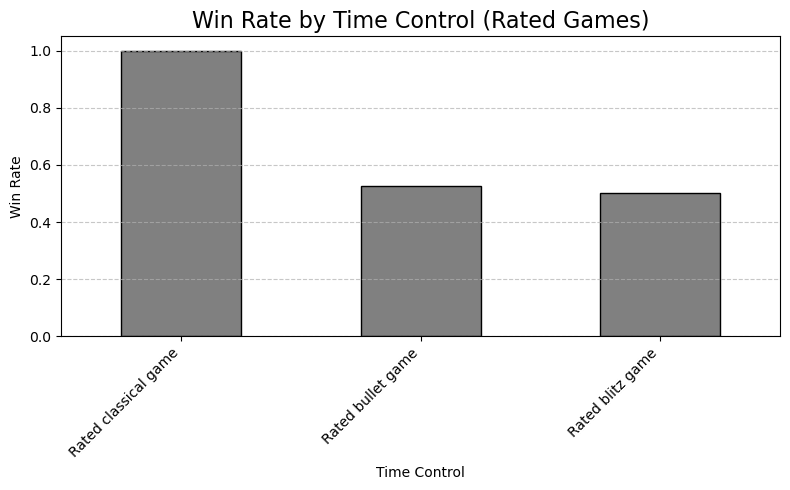

In [7]:
ranked_df = df[df['Event'].isin(RANKED_EVENTS)]

win_rate_by_mode = ranked_df.groupby('Event')['ResultStatus'].apply(lambda x: (x == 'win').mean())

plt.figure(figsize=(8, 5))
win_rate_by_mode.sort_values(ascending=False).plot(kind='bar', color='grey', edgecolor='black')
plt.title('Win Rate by Time Control (Rated Games)', fontsize=16)
plt.xlabel('Time Control')
plt.ylabel('Win Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 5.2 White pieces or Black pieces?

Garry Kasparov: *"It is undeniable that White's first move confers a small
but persistent advantage."* Does that show up here?


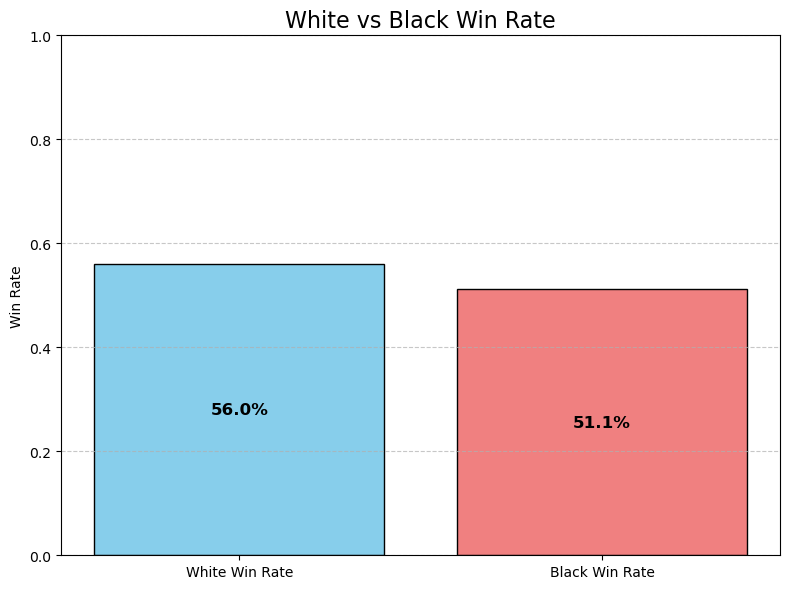

In [8]:
white_win_rate = df[(df['White'] == NICKNAME) & (df['ResultStatus'] == 'win')].shape[0] / (df['White'] == NICKNAME).sum()
black_win_rate = df[(df['Black'] == NICKNAME) & (df['ResultStatus'] == 'win')].shape[0] / (df['Black'] == NICKNAME).sum()

categories = ['White Win Rate', 'Black Win Rate']
win_rates = [white_win_rate, black_win_rate]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(categories, win_rates, color=['skyblue', 'lightcoral'], edgecolor='black')
for bar, rate in zip(bars, win_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{rate:.1%}',
            ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_title('White vs Black Win Rate', fontsize=16)
ax.set_ylabel('Win Rate')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 5.3 How has my activity changed over time?


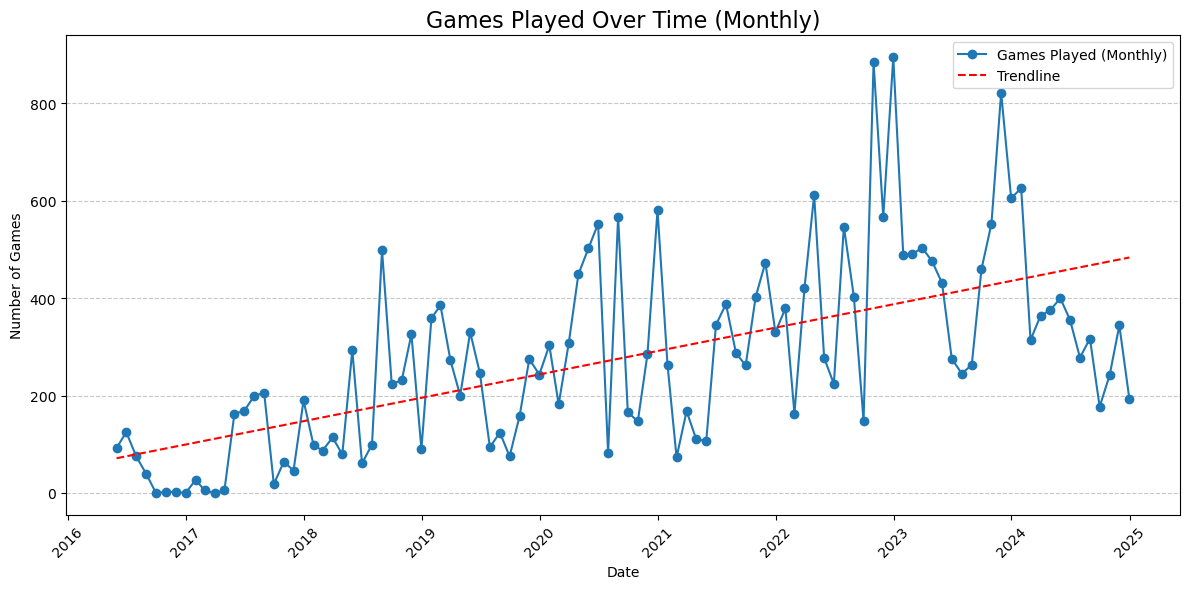

In [9]:
games_over_time_monthly = df.groupby('Date').size().resample('M').sum()

plt.figure(figsize=(12, 6))
plt.plot(games_over_time_monthly.index, games_over_time_monthly.values, marker='o', label='Games Played (Monthly)')

ordinal_dates = games_over_time_monthly.index.map(lambda x: x.toordinal())
z = np.polyfit(ordinal_dates, games_over_time_monthly.values, 1)
trend = np.poly1d(z)
plt.plot(games_over_time_monthly.index, trend(ordinal_dates), linestyle='--', color='red', label='Trendline')

plt.title('Games Played Over Time (Monthly)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


### 5.4 Does my win rate change across opponent Elo ranges?


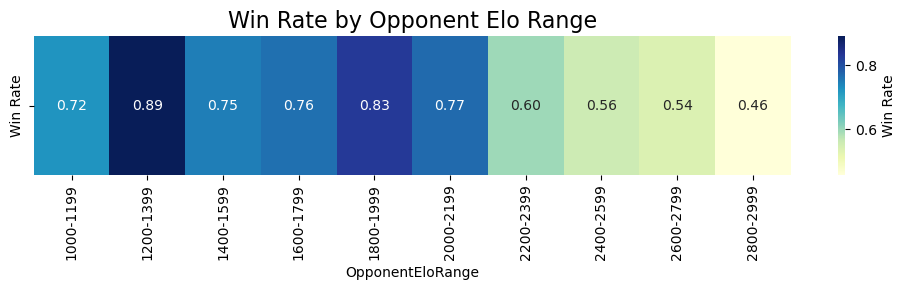

In [10]:
win_rate_by_elo = (
    df[df['ResultStatus'] == 'win'].groupby('OpponentEloRange', observed=False).size()
    / df.groupby('OpponentEloRange', observed=False).size()
).fillna(0).to_frame(name='Win Rate')

plt.figure(figsize=(10, 3))
sns.heatmap(win_rate_by_elo.T, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Win Rate'})
plt.title('Win Rate by Opponent Elo Range', fontsize=16)
plt.tight_layout()
plt.show()


### 5.5 What time of day do I perform best?


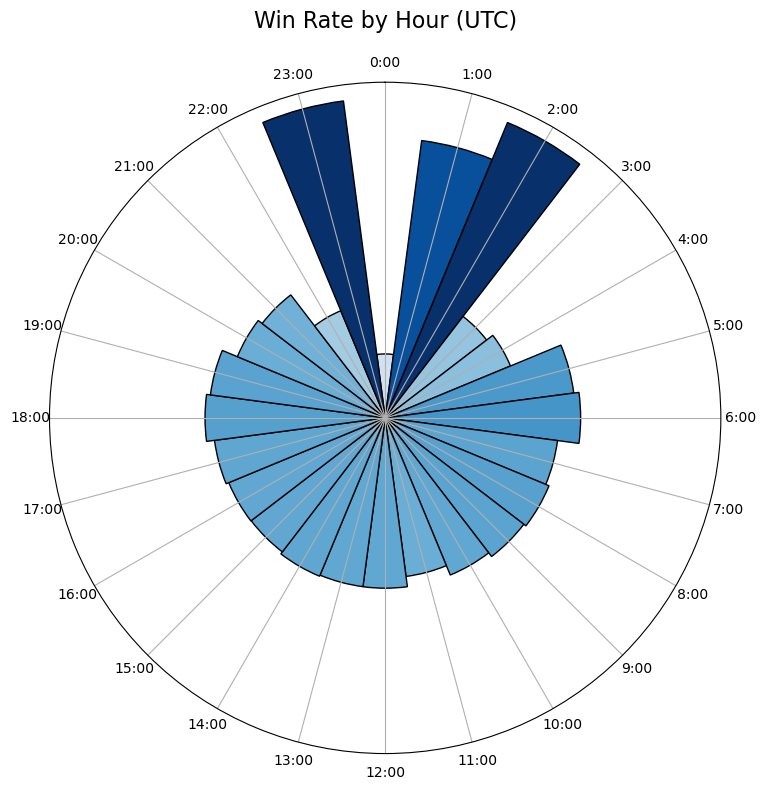

In [11]:
win_rate_by_hour = (
    df[df['ResultStatus'] == 'win'].groupby('Hour').size() / df.groupby('Hour').size()
).fillna(0)

angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)
max_rate = win_rate_by_hour.max()
normalized = win_rate_by_hour / max_rate

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
for i, hour in enumerate(win_rate_by_hour.index):
    ax.bar(angles[i], normalized[hour] * 0.3, width=np.radians(15),
           color=plt.cm.Blues(normalized[hour]), edgecolor='black')

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels([f'{h}:00' for h in win_rate_by_hour.index])
ax.set_yticks([])
ax.set_title('Win Rate by Hour (UTC)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


## 6. Opening Analysis

Restricted to rated bullet games, the mode with by far the largest sample
size.


In [12]:
ranked_bullet_df = df[df['Event'] == 'Rated bullet game']


### 6.1 Best openings playing White

In [13]:
white_games = ranked_bullet_df[ranked_bullet_df['White'] == NICKNAME]
white_opening_stats = white_games.groupby('Opening').agg(
    game_count=('ResultStatus', 'size'),
    win_rate=('ResultStatus', lambda x: (x == 'win').mean()),
).reset_index()
white_opening_stats = white_opening_stats[white_opening_stats['game_count'] >= 50]

fig = px.treemap(
    white_opening_stats, path=['Opening'], values='game_count', color='win_rate',
    hover_data=['win_rate'], color_continuous_scale='YlGn',
    title='Win Rate by Opening — White Side (Ranked Bullet)',
)
fig.update_traces(textinfo='label+percent entry')
fig.show()


### 6.2 Best openings playing Black

In [14]:
black_games = ranked_bullet_df[ranked_bullet_df['Black'] == NICKNAME]
black_opening_stats = black_games.groupby('Opening').agg(
    game_count=('ResultStatus', 'size'),
    win_rate=('ResultStatus', lambda x: (x == 'win').mean()),
).reset_index()
black_opening_stats = black_opening_stats[black_opening_stats['game_count'] >= 50]

fig = px.treemap(
    black_opening_stats, path=['Opening'], values='game_count', color='win_rate',
    hover_data=['win_rate'], color_continuous_scale='Greys',
    title='Win Rate by Opening — Black Side (Ranked Bullet)',
)
fig.update_traces(textinfo='label+percent entry')
fig.show()


### 6.3 Best opening overall **[RECONSTRUCTED]**

`opening_stats` — combining the White-side and Black-side tables above into
one ranked list — was used by the original "Best Opening For Me" chart, but
the cell that built it was missing. `build_opening_stats` reproduces it:
White and Black game/win counts per opening are summed, then the win rate
is recomputed on the combined totals.


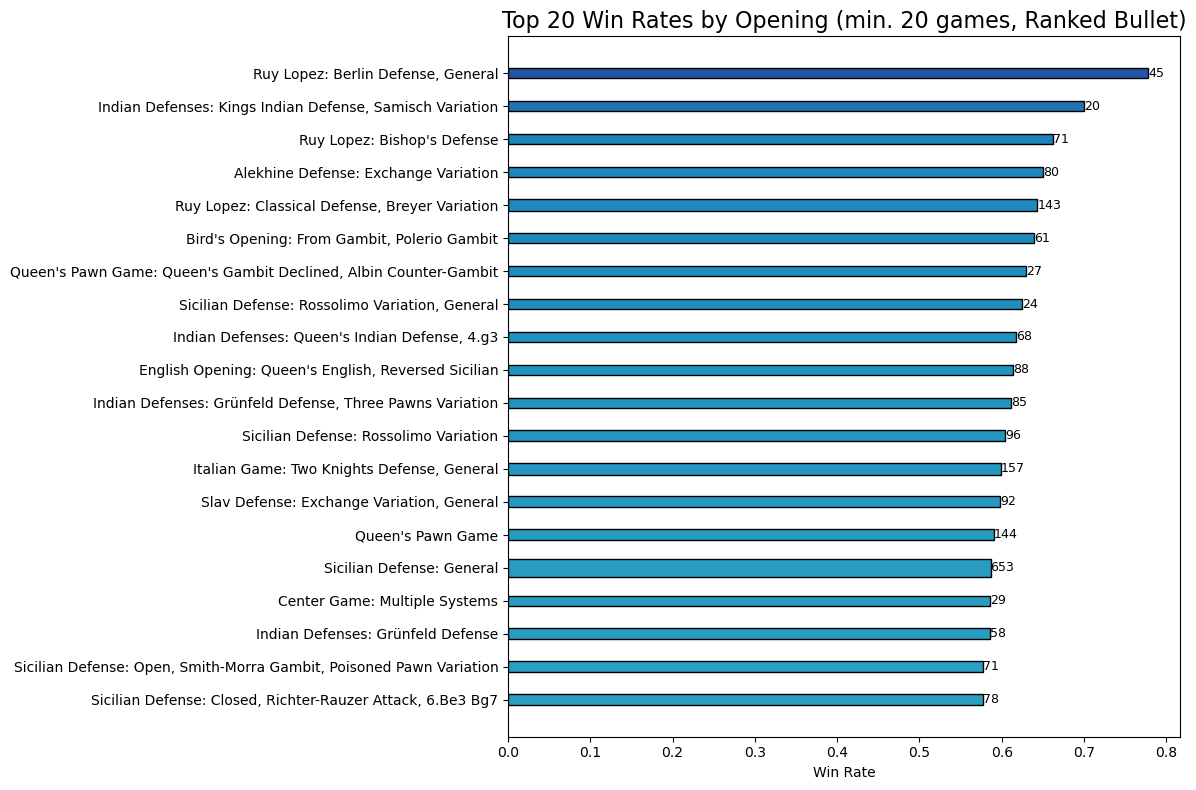

In [15]:
opening_stats = build_opening_stats(df, event='Rated bullet game', min_games=20)
top_20 = opening_stats.sort_values('win_rate', ascending=False).head(20)

cmap = plt.colormaps['YlGnBu']
plt.figure(figsize=(12, 8))
colors = cmap(top_20['win_rate'])
bars = plt.barh(top_20['Opening'], top_20['win_rate'], height=top_20['normalized_size'],
                 color=colors, edgecolor='black')
for bar, count in zip(bars, top_20['game_count']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{int(count)}',
              va='center', ha='left', fontsize=9)

plt.title('Top 20 Win Rates by Opening (min. 20 games, Ranked Bullet)', fontsize=16)
plt.xlabel('Win Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Hypothesis Testing

### 7.1 Do I perform the same against much higher-rated opponents?

- **H0:** win rate against opponents rated above 2900 is the same as against everyone else.
- **H1:** my performance declines against opponents rated above 2900.


T-statistic: -23.217
P-value: 5.052e-113
Reject H0: significant difference in win rate.


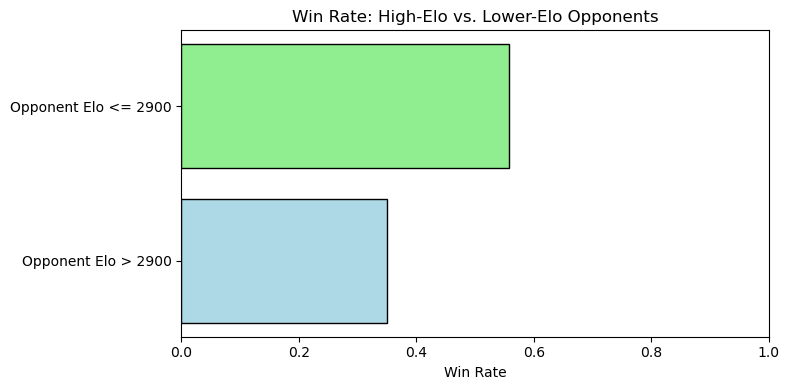

In [16]:
ranked_bullet_df = ranked_bullet_df.copy()
ranked_bullet_df['HighEloOpponent'] = ranked_bullet_df['OpponentElo'] > 2900
ranked_bullet_df['WinFlag'] = (ranked_bullet_df['ResultStatus'] == 'win').astype(int)

high_elo = ranked_bullet_df[ranked_bullet_df['HighEloOpponent']]['WinFlag']
low_elo = ranked_bullet_df[~ranked_bullet_df['HighEloOpponent']]['WinFlag']

t_stat, p_value = stats.ttest_ind(high_elo, low_elo, equal_var=False)
print(f'T-statistic: {t_stat:.3f}')
print(f'P-value: {p_value:.3e}')
print('Reject H0: significant difference in win rate.' if p_value < 0.05 else 'Fail to reject H0.')

plt.figure(figsize=(8, 4))
plt.barh(['Opponent Elo > 2900', 'Opponent Elo <= 2900'], [high_elo.mean(), low_elo.mean()],
         color=['lightblue', 'lightgreen'], edgecolor='black')
plt.title('Win Rate: High-Elo vs. Lower-Elo Opponents')
plt.xlabel('Win Rate')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


### 7.2 Is my success driven by playing smart, or by playing fast?

Comparing games decided normally (checkmate/resignation — "smart") against
games decided on the clock ("Time forfeit" — "fast").


T-statistic: -57.641
P-value: 0.000e+00
Reject H0: significant difference in outcome by termination type.


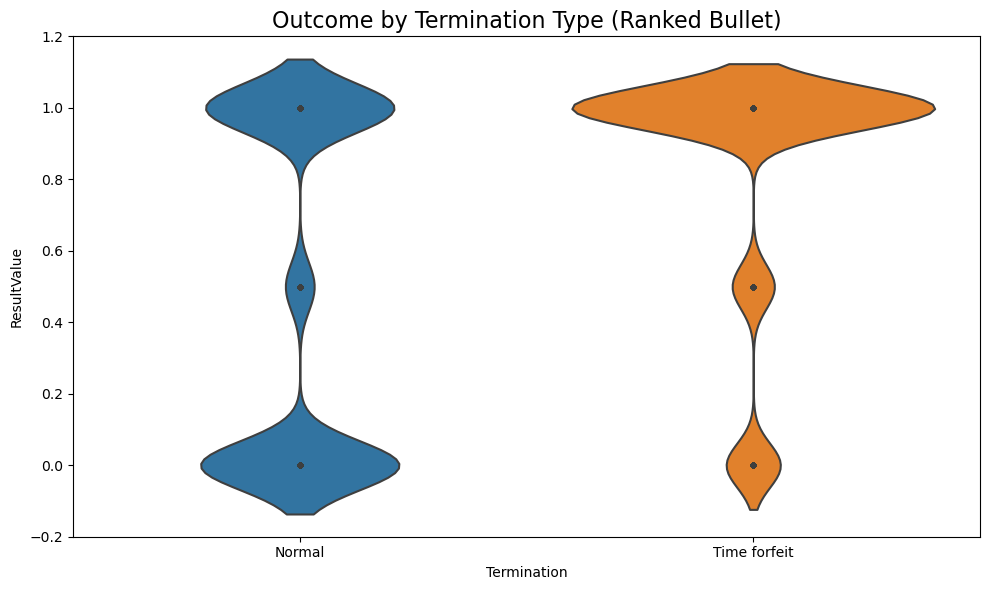

In [17]:
ranked_bullet_df['ResultValue'] = ranked_bullet_df['ResultStatus'].map({'win': 1, 'loss': 0, 'draw': 0.5})

normal = ranked_bullet_df[ranked_bullet_df['Termination'] == 'Normal']['ResultValue'].dropna()
time_forfeit = ranked_bullet_df[ranked_bullet_df['Termination'] == 'Time forfeit']['ResultValue'].dropna()

t_stat, p_value = stats.ttest_ind(normal, time_forfeit, equal_var=False)
print(f'T-statistic: {t_stat:.3f}')
print(f'P-value: {p_value:.3e}')
print('Reject H0: significant difference in outcome by termination type.' if p_value < 0.05 else 'Fail to reject H0.')

plt.figure(figsize=(10, 6))
sns.violinplot(data=ranked_bullet_df.dropna(subset=['ResultValue']), x='Termination', y='ResultValue', inner='point')
plt.title('Outcome by Termination Type (Ranked Bullet)', fontsize=16)
plt.tight_layout()
plt.show()


## 8. Machine Learning — Which factor drives the outcome most? **[RECONSTRUCTED]**

The feature engineering, train/test split and scaling for this model were
lost along with the other missing cells. `build_ml_dataset` reconstructs a
feature table from the exact factors examined individually above — rating
gap, piece color, time-forfeit terminations and hour of day — so the model
answers the same question ("which of these matters most?") using the
sections already built.

Target: `ResultClass` (`win` = 1, `draw` = 0, `loss` = -1).


In [18]:
ml_df = build_ml_dataset(df, event='Rated bullet game')
X = ml_df[ML_FEATURES]
y = ml_df['ResultClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Class distribution before oversampling:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('\nClass distribution after oversampling:')
print(pd.Series(y_train_res).value_counts())


Class distribution before oversampling:
ResultClass
 1    9509
-1    7217
 0    1340
Name: count, dtype: int64

Class distribution after oversampling:
ResultClass
 1    9509
-1    9509
 0    9509
Name: count, dtype: int64


In [19]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.5798096081470002

              precision    recall  f1-score   support

          -1       0.55      0.74      0.63      1804
           0       0.10      0.08      0.09       335
           1       0.70      0.53      0.60      2378

    accuracy                           0.58      4517
   macro avg       0.45      0.45      0.44      4517
weighted avg       0.59      0.58      0.58      4517



**Feature importance:** with three outcome classes, `model.coef_` has
one row per class. The chart below averages the absolute coefficient
across all three classes per feature, giving a single overall-impact
ranking (the original notebook's cached output implies it looked only at
one class's coefficients — this version uses the more defensible mean
across all classes).


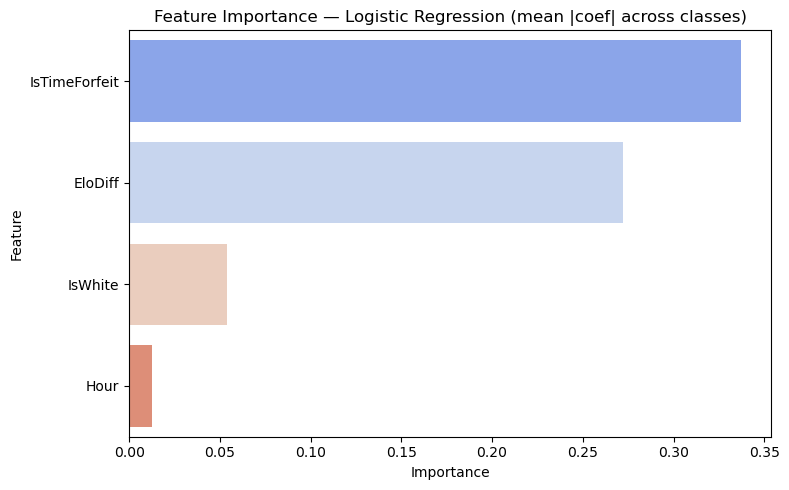

In [20]:
importance = np.mean(np.abs(model.coef_), axis=0)
feature_importance = pd.DataFrame({'Feature': ML_FEATURES, 'Importance': importance})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')
plt.title('Feature Importance — Logistic Regression (mean |coef| across classes)')
plt.tight_layout()
plt.show()


## 9. Key Findings

See the project [README](../README.md) for the summarized takeaways used
in the portfolio write-up.
